<a href="https://colab.research.google.com/github/Western-Windows/SociaLift/blob/engagement/engagement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
# 0. Install dependencies (Colab / local with internet)
%pip install -q transformers datasets accelerate sentencepiece scikit-learn torch tqdm

In [109]:
# 1. Imports and configuration

import json
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSeq2SeqLM,
    get_linear_schedule_with_warmup
)

tqdm.pandas()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [110]:
import json
import numpy as np
import pandas as pd
from tqdm import tqdm

# -------------------------------------------------------------
# 1) Load Brand Data & Build Follower Map
# -------------------------------------------------------------
with open('Facebook_Brand_Data_Analysis.json', 'r', encoding='utf-8') as f:
    brand_metadata = json.load(f)

# Helper function to convert "43M", "~450K" to numeric
def parse_followers(f_str):
    if not isinstance(f_str, str):
        return f_str

    # Remove tilde and commas, make uppercase
    f_str = f_str.replace('~', '').replace(',', '').strip().upper()
    multiplier = 1

    if 'K' in f_str:
        multiplier = 1000
        f_str = f_str.replace('K', '')
    elif 'M' in f_str:
        multiplier = 1000000
        f_str = f_str.replace('M', '')

    try:
        return int(float(f_str) * multiplier)
    except ValueError:
        return np.nan

# Build dictionary matching brand/username to follower count
followers_map = {}
for brand in brand_metadata:
    followers_num = parse_followers(brand.get('Followers', ''))

    username = str(brand.get('Username', '')).lower()
    brand_name = str(brand.get('Brand Name', '')).lower()

    if username: followers_map[username] = followers_num
    if brand_name: followers_map[brand_name] = followers_num

# Aliases to fix slight name mismatches between the two files
aliases = {
    'arrow 1851': 'arrow',
    'clarks shoes': 'clarks',
    'h&m': 'hm',
    'redtape': 'red tape'
}

# -------------------------------------------------------------
# 2) Load Posts Data & Process Rows
# -------------------------------------------------------------
with open('dataset.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

flattened_rows = []

for file_key, doc in tqdm(raw_data.items()):
    posts = doc.get('data', [])
    for post in posts:
        row = {}
        owing_profile = post.get('owing_profile', {})

        # Core Post Details
        row['page_name'] = owing_profile.get('name') or owing_profile.get('short_name')
        row['post_text'] = post.get('context')
        row['date_of_publish'] = post.get('published_date')

        # Pull followers using the map and fallback to our aliases to ensure strict matching
        search_key = str(row['page_name']).lower()
        search_key = aliases.get(search_key, search_key)
        row['page_followers'] = followers_map.get(search_key, np.nan)

        # Sub-reactions mapped from Arabic terms
        sub_reactions = post.get('sub_reactions', {}) or {}
        row['like_count']  = sub_reactions.get('أعجبني', 0)
        row['love_count']  = sub_reactions.get('أحببته', 0)
        row['haha_count']  = sub_reactions.get('هاهاها', 0)
        row['wow_count']   = sub_reactions.get('واااو', 0)
        row['sad_count']   = sub_reactions.get('أحزنني', 0)
        row['angry_count'] = sub_reactions.get('أغضبني', 0)
        row['care_count']  = sub_reactions.get('أدعمه', 0)

        # High-level reaction and share stats
        row['total_reactions'] = post.get('reaction_count.count', 0)
        row['comments_count']  = post.get('comment_rendering_instance.comments.total_count', 0)
        row['share_count']     = post.get('share_count.count', 0)

        flattened_rows.append(row)

posts_df = pd.DataFrame(flattened_rows)

# -------------------------------------------------------------
# 3) Calculate Engagement Scores & Labels
# -------------------------------------------------------------
# 3) Centralised reaction/share weights
reaction_weights = {
    'like_count': 1.0,
    'love_count': 2.0,
    'haha_count': 1.5,
    'wow_count': 1.5,
    'sad_count': 0.5,
    'angry_count': 0.5,
    'care_count': 1.5,
    'share_count': 3.0
}

# Ensure numeric columns
numeric_cols = list(reaction_weights.keys()) + ['page_followers']
for col in numeric_cols:
    if col in posts_df.columns:
        posts_df[col] = pd.to_numeric(posts_df[col], errors='coerce').fillna(0)

# Weighted engagement
posts_df['engagement_weighted'] = 0.0
for col, w in reaction_weights.items():
    if col in posts_df.columns:
        posts_df['engagement_weighted'] = posts_df['engagement_weighted'] + w * posts_df[col]

# Engagement rate
followers_series = posts_df['page_followers'].replace(0, pd.NA)
posts_df['engagement_rate'] = posts_df['engagement_weighted'] / followers_series
posts_df['engagement_rate'] = posts_df['engagement_rate'].fillna(0)


# Quantile-based engagement labelling
posts_df['engagement_label'] = pd.qcut(
    posts_df['engagement_rate'],
    q=3,
    labels=['low', 'avg', 'high'],
    duplicates='drop'
)
# Save out the completed and verified CSV file
posts_df.to_csv('final_dataset_with_followers.csv', index=False)

print(posts_df[['page_name', 'page_followers', 'engagement_weighted', 'engagement_rate', 'engagement_label']].head())



100%|██████████| 24/24 [00:00<00:00, 6782.78it/s]

  page_name  page_followers  engagement_weighted  engagement_rate  \
0    adidas      43000000.0               1156.0         0.000027   
1    adidas      43000000.0                169.0         0.000004   
2    adidas      43000000.0                252.0         0.000006   
3    adidas      43000000.0                181.0         0.000004   
4    adidas      43000000.0                177.5         0.000004   

  engagement_label  
0              avg  
1              low  
2              low  
3              low  
4              low  



/tmp/ipykernel_449/436052046.py:125: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  posts_df['engagement_rate'] = posts_df['engagement_rate'].fillna(0)


In [111]:
#gemini eda

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure date is datetime
posts_df['date_of_publish'] = pd.to_datetime(posts_df['date_of_publish'], errors='coerce')

# Set aesthetic style
sns.set_theme(style="whitegrid")

# 1. Distribution of Engagement Label
plt.figure(figsize=(8, 5))
sns.countplot(data=posts_df, x='engagement_label', order=['low', 'avg', 'high'], palette='viridis')
plt.title('Distribution of Engagement Labels')
plt.xlabel('Engagement Label')
plt.ylabel('Count')
plt.savefig('engagement_label_dist.png', bbox_inches='tight')
plt.close()

# 2. Top 10 Pages by Number of Posts
plt.figure(figsize=(10, 6))
top_pages = posts_df['page_name'].value_counts().nlargest(10)
sns.barplot(y=top_pages.index, x=top_pages.values, palette='Blues_r')
plt.title('Top 10 Pages by Number of Posts')
plt.xlabel('Number of Posts')
plt.ylabel('Page Name')
plt.savefig('top_pages_posts.png', bbox_inches='tight')
plt.close()

# 3. Average Engagement Rate by Top 10 Pages
plt.figure(figsize=(10, 6))
top_eng_pages = posts_df.groupby('page_name')['engagement_rate'].mean().nlargest(10)
sns.barplot(y=top_eng_pages.index, x=top_eng_pages.values, palette='Oranges_r')
plt.title('Top 10 Pages by Average Engagement Rate')
plt.xlabel('Average Engagement Rate')
plt.ylabel('Page Name')
plt.savefig('top_eng_pages.png', bbox_inches='tight')
plt.close()

# 4. Correlation Matrix of Metrics
plt.figure(figsize=(10, 8))
corr_cols = ['page_followers', 'like_count', 'love_count', 'haha_count', 'wow_count',
             'sad_count', 'angry_count', 'care_count', 'total_reactions',
             'comments_count', 'share_count', 'engagement_weighted', 'engagement_rate']
corr = posts_df[corr_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Engagement Metrics')
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.close()

# 5. Time Series of Posts over Time
plt.figure(figsize=(12, 5))
posts_df.set_index('date_of_publish').resample('M').size().plot(color='teal', linewidth=2)
plt.title('Number of Posts Over Time (Monthly)')
plt.xlabel('Date of Publish')
plt.ylabel('Post Count')
plt.grid(True)
plt.savefig('posts_over_time.png', bbox_inches='tight')
plt.close()

# Summary statistics for text response
summary_stats = posts_df.describe().to_dict()
missing_values = posts_df.isnull().sum().to_dict()

print("Plots generated successfully.")
print(posts_df['page_name'].nunique(), "unique pages.")
print(posts_df.shape[0], "total posts.")

/tmp/ipykernel_449/154807405.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=posts_df, x='engagement_label', order=['low', 'avg', 'high'], palette='viridis')
/tmp/ipykernel_449/154807405.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_pages.index, x=top_pages.values, palette='Blues_r')
/tmp/ipykernel_449/154807405.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_eng_pages.index, x=top_eng_pages.values, palette='Oranges_r')
/tmp/ipykernel_449/154807405.py:56: FutureWarning: 'M' is deprecated and will be remove

Plots generated successfully.
25 unique pages.
551 total posts.


  page_name                                          post_text  \
0    adidas  The new standard for Hybrid Fitness Racing.\n\...   
1    adidas  Together, adidas and the Kolisi Foundation are...   
2    adidas  To every athlete who makes us believe, Grazie ...   
3    adidas  Untouched. 🥇\n\n@lauranolte and @deborah.levi ...   
4    adidas  Different relay. Same result for @lou_jml.\n\n...   

      date_of_publish  page_followers  like_count  love_count  haha_count  \
0 2026-02-25 11:07:53      43000000.0         599         111           2   
1 2026-02-25 09:00:41      43000000.0         110          18           0   
2 2026-02-22 20:28:45      43000000.0         152          24           0   
3 2026-02-21 22:01:09      43000000.0         130          14           0   
4 2026-02-18 14:57:49      43000000.0         117          11           0   

   wow_count  sad_count  angry_count  care_count  total_reactions  \
0         10          0            4           6              732   
1 

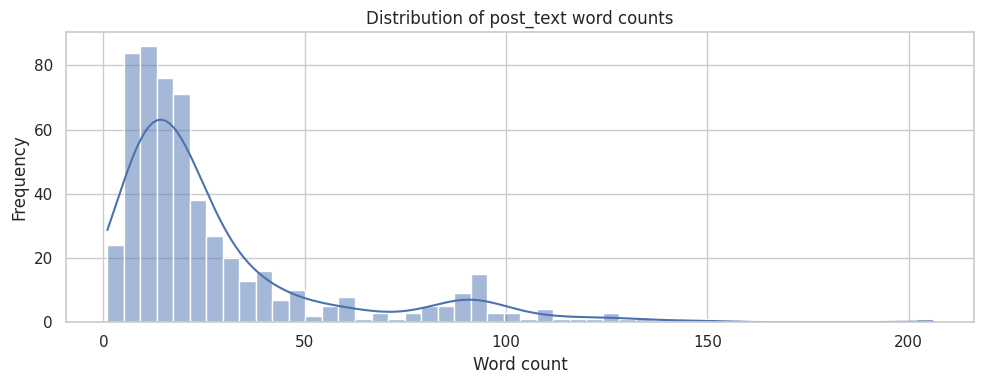

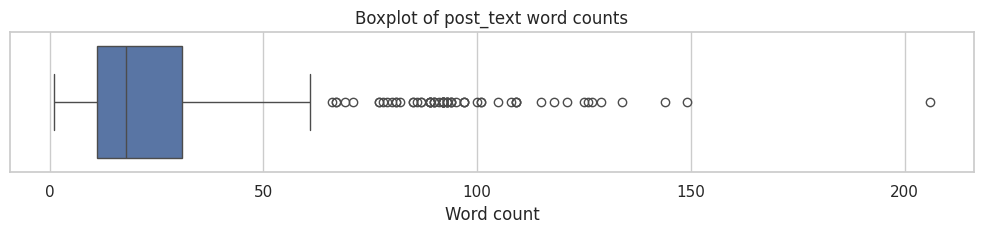

100%|██████████| 551/551 [00:00<00:00, 1959.51it/s]


                                           post_text  \
0  The new standard for Hybrid Fitness Racing.\n\...   
1  Together, adidas and the Kolisi Foundation are...   
2  To every athlete who makes us believe, Grazie ...   
3  Untouched. 🥇\n\n@lauranolte and @deborah.levi ...   
4  Different relay. Same result for @lou_jml.\n\n...   

                                     post_text_clean  
0  new standard hybrid fitness racing adizero dro...  
1  together adidas kolisi foundation breaking bar...  
2  every athlete make u believe grazie mille mila...  
3  untouched lauranolte deborahlevi complete miss...  
4  different relay result loujml claw back 13 pla...  
final_dataset_with_followers_processed.csv


In [112]:
# julius EDA with Preprocessing
# 1. Imports and setup
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Make plots look a bit nicer
sns.set(style="whitegrid")

# 2. Ensure NLTK resources are available
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    nltk.download('punkt')
    nltk.download('wordnet')

# Quick look at the data
print(posts_df.head())

# 4. Basic text EDA on post_text
posts_df['post_text'] = posts_df['post_text'].astype(str)

# Length features
posts_df['text_length_chars'] = posts_df['post_text'].str.len()
posts_df['text_length_words'] = posts_df['post_text'].str.split().apply(len)

# Summary statistics of lengths
print(posts_df[['text_length_chars', 'text_length_words']].describe())

# Distribution of word counts
plt.figure(figsize=(10, 4))
sns.histplot(posts_df['text_length_words'], bins=50, kde=True)
plt.title('Distribution of post_text word counts')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Boxplot of word counts
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=posts_df['text_length_words'])
plt.title('Boxplot of post_text word counts')
plt.xlabel('Word count')
plt.tight_layout()
plt.show()

# 5. Preprocessing functions
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove URLs (fixed double backslash)
    text = re.sub(r"http\S+", " ", text)

    # Explicitly remove punctuation using string.punctuation (fastest method)
    # This translates all punctuation characters to None (removes them)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove any remaining non-alphanumeric characters (keep spaces)
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Normalize whitespace (fixed double backslash)
    text = re.sub(r"\s+", " ", text).strip()

    return text

def preprocess_text(text):
    cleaned = clean_text(text)
    tokens = cleaned.split()
    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# 6. Apply preprocessing with progress bar
tqdm.pandas()
posts_df['post_text_clean'] = posts_df['post_text'].progress_apply(preprocess_text)

# Inspect original vs cleaned
print(posts_df[['post_text', 'post_text_clean']].head())

# 7. Save processed dataset
output_path = 'final_dataset_with_followers_processed.csv'
posts_df.to_csv(output_path, index=False)
print(output_path)

In [113]:
# 4. Optional translation (only run if you *definitely* need it)

translate = True  # Set to True if you want to translate

if translate:
    translation_model_name = "Helsinki-NLP/opus-mt-mul-en"
    trans_tokenizer = AutoTokenizer.from_pretrained(translation_model_name)
    trans_model = AutoModelForSeq2SeqLM.from_pretrained(translation_model_name).to(device)

    def translate_batch(texts, max_length=128, batch_size=16):
        out = []
        for i in tqdm(range(0, len(texts), batch_size), desc="Translating"):
            batch = texts[i:i+batch_size]
            enc = trans_tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length
            ).to(device)
            with torch.no_grad():
                gen = trans_model.generate(**enc, max_length=max_length)
            decoded = trans_tokenizer.batch_decode(gen, skip_special_tokens=True)
            out.extend(decoded)
        return out

    # Using post_text directly if translation is skipped, or creating the translated column
    posts_df["post_text_en"] = translate_batch(posts_df["post_text_clean"].astype(str).tolist())
else:
    # If no translation, we use the original text for the following steps
    posts_df["post_text_en"] = posts_df["post_text_clean"].astype(str)

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Translating: 100%|██████████| 35/35 [00:49<00:00,  1.43s/it]


In [114]:
# 5. Train/validation split and label encoding

label_encoder = LabelEncoder()
posts_df["label_id"] = label_encoder.fit_transform(posts_df["engagement_label"].astype(str))
num_labels = len(label_encoder.classes_)
print("Labels:", list(label_encoder.classes_), "num_labels:", num_labels)

train_df, val_df = train_test_split(
    posts_df,
    test_size=0.2,
    random_state=42,
    stratify=posts_df["label_id"]
)

print("Train size:", len(train_df), "Val size:", len(val_df))

Labels: ['avg', 'high', 'low'] num_labels: 3
Train size: 440 Val size: 111


TF-IDF + LR accuracy: 0.4864864864864865
TF-IDF + LR macro F1: 0.4862048283100915
              precision    recall  f1-score   support

         avg       0.41      0.49      0.44        37
        high       0.54      0.41      0.46        37
         low       0.54      0.57      0.55        37

    accuracy                           0.49       111
   macro avg       0.49      0.49      0.49       111
weighted avg       0.49      0.49      0.49       111



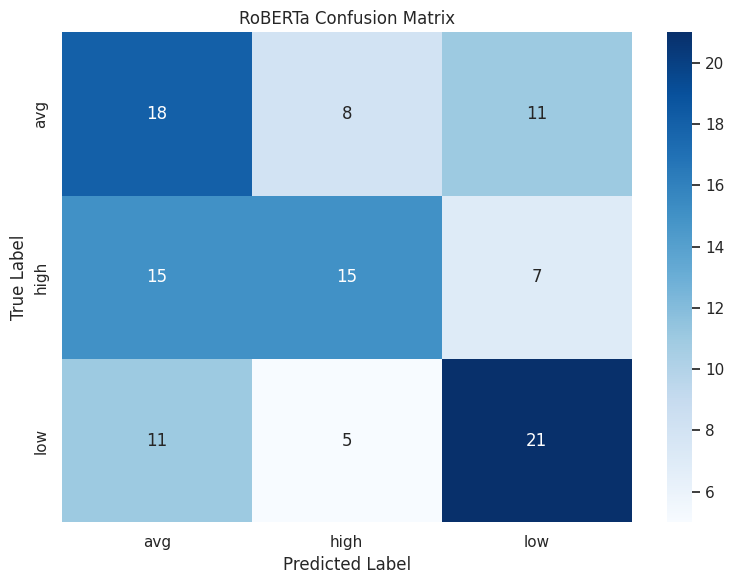

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# 6. TF-IDF + Logistic Regression baseline

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_tfidf = tfidf.fit_transform(train_df["post_text_en"])
X_val_tfidf = tfidf.transform(val_df["post_text_en"])

log_reg = LogisticRegression(
    max_iter=200,
    n_jobs=-1,
    class_weight="balanced"
)
log_reg.fit(X_train_tfidf, train_df["label_id"])

val_pred_lr = log_reg.predict(X_val_tfidf)
val_pred_lr_proba = log_reg.predict_proba(X_val_tfidf)

print("TF-IDF + LR accuracy:", accuracy_score(val_df["label_id"], val_pred_lr))
print("TF-IDF + LR macro F1:", f1_score(val_df["label_id"], val_pred_lr, average="macro"))
print(classification_report(val_df["label_id"], val_pred_lr, target_names=label_encoder.classes_))
# Calculate the confusion matrix
cm = confusion_matrix(val_df["label_id"], val_pred_lr)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title('logistic+tf idf Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [116]:
# 7. Torch dataset for transformer models

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            "text": self.texts[idx],
            "label": int(self.labels[idx])
        }

In [117]:
# 8. Generic training utilities (works for BERT and RoBERTa models)

def collate_fn_builder(tokenizer, max_length=128):
    def collate(batch):
        texts = [item["text"] for item in batch]
        labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
        enc = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        enc["labels"] = labels
        return enc
    return collate

def train_transformer_classifier(
    model,
    tokenizer,
    train_df,
    val_df,
    num_epochs=3,
    batch_size=16,
    max_length=128,
    lr=2e-5,
    warmup_ratio=0.1
):
    train_dataset = TextDataset(train_df["post_text_en"], train_df["label_id"])
    val_dataset = TextDataset(val_df["post_text_en"], val_df["label_id"])

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn_builder(tokenizer, max_length)
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn_builder(tokenizer, max_length)
    )

    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    num_training_steps = num_epochs * len(train_loader)
    num_warmup_steps = int(warmup_ratio * num_training_steps)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )

    best_f1 = 0.0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - train"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        model.eval()
        all_labels = []
        all_preds = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - val"):
                labels = batch["labels"].numpy()
                all_labels.extend(labels)

                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                logits = outputs.logits
                preds = torch.argmax(logits, dim=-1).cpu().numpy()
                all_preds.extend(preds)

        f1 = f1_score(all_labels, all_preds, average="macro")
        acc = accuracy_score(all_labels, all_preds)
        print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, val_acc={acc:.4f}, val_macro_f1={f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            best_state = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    return model, best_f1

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1/3 - val: 100%|██████████| 7/7

Epoch 1: train_loss=1.0978, val_acc=0.4234, val_macro_f1=0.3586


Epoch 2/3 - val: 100%|██████████| 7/7 [00:00<00:00, 14.12it/s]


Epoch 2: train_loss=0.9807, val_acc=0.4595, val_macro_f1=0.4176


Epoch 3/3 - val: 100%|██████████| 7/7 [00:00<00:00, 13.75it/s]


Epoch 3: train_loss=0.8955, val_acc=0.4595, val_macro_f1=0.4345
BERT accuracy: 0.4594594594594595
BERT macro F1: 0.43447754978153297
              precision    recall  f1-score   support

         avg       0.44      0.19      0.26        37
        high       0.45      0.54      0.49        37
         low       0.47      0.65      0.55        37

    accuracy                           0.46       111
   macro avg       0.45      0.46      0.43       111
weighted avg       0.45      0.46      0.43       111



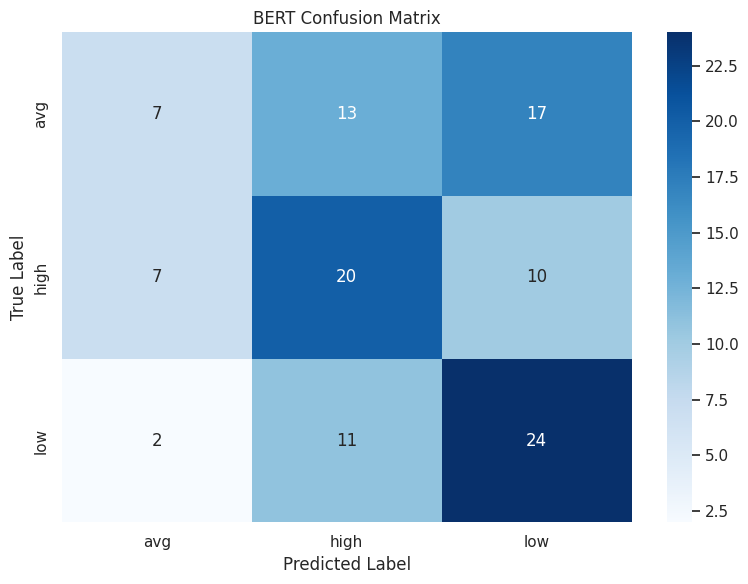

In [118]:
# 9. BERT-base classifier with explicit softmax on top
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


from transformers import AutoModelForSequenceClassification, AutoTokenizer

bert_model_name = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_model_name,
    num_labels=num_labels
)

bert_model, bert_best_f1 = train_transformer_classifier(
    bert_model,
    bert_tokenizer,
    train_df,
    val_df,
    num_epochs=3,
    batch_size=16,
    max_length=128,
    lr=2e-5
)

def bert_predict_with_softmax(texts):
    bert_model.eval()
    bert_model.to(device)
    enc = bert_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        outputs = bert_model(**enc)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    preds = np.argmax(probs, axis=1)
    labels = label_encoder.inverse_transform(preds)
    return labels, probs

val_labels = val_df["label_id"].values
_, bert_probs = bert_predict_with_softmax(val_df["post_text_en"].tolist())
bert_preds = np.argmax(bert_probs, axis=1)

print("BERT accuracy:", accuracy_score(val_labels, bert_preds))
print("BERT macro F1:", f1_score(val_labels, bert_preds, average="macro"))
print(classification_report(val_labels, bert_preds, target_names=label_encoder.classes_))
# Calculate the confusion matrix
cm = confusion_matrix(val_labels, bert_preds)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title('BERT Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1/3 - val: 100%|██████████| 7/7 [00:00<00:00, 14.11it/s]


Epoch 1: train_loss=1.1014, val_acc=0.4685, val_macro_f1=0.4607


Epoch 2/3 - val: 100%|██████████| 7/7 [00:00<00:00, 13.55it/s]


Epoch 2: train_loss=1.0891, val_acc=0.4054, val_macro_f1=0.3768


Epoch 3/3 - val: 100%|██████████| 7/7 [00:00<00:00, 12.79it/s]


Epoch 3: train_loss=1.0201, val_acc=0.5495, val_macro_f1=0.5353
RoBERTa accuracy: 0.5495495495495496
RoBERTa macro F1: 0.5352574659639877
              precision    recall  f1-score   support

         avg       0.55      0.43      0.48        37
        high       0.55      0.81      0.65        37
         low       0.56      0.41      0.47        37

    accuracy                           0.55       111
   macro avg       0.55      0.55      0.54       111
weighted avg       0.55      0.55      0.54       111



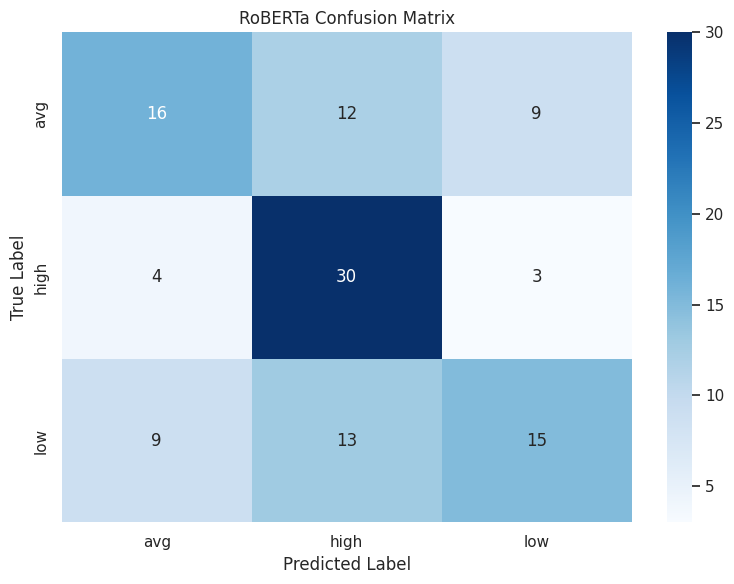

In [119]:
# 10. RoBERTa-base classifier with explicit softmax on top

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

roberta_model_name = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_model_name)

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name,
    num_labels=num_labels
)

roberta_model, roberta_best_f1 = train_transformer_classifier(
    roberta_model,
    roberta_tokenizer,
    train_df,
    val_df,
    num_epochs=3,
    batch_size=16,
    max_length=128,
    lr=2e-5
)

def roberta_predict_with_softmax(texts):
    roberta_model.eval()
    roberta_model.to(device)
    enc = roberta_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        outputs = roberta_model(**enc)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    preds = np.argmax(probs, axis=1)
    labels = label_encoder.inverse_transform(preds)
    return labels, probs

_, roberta_probs = roberta_predict_with_softmax(val_df["post_text_en"].tolist())
roberta_preds = np.argmax(roberta_probs, axis=1)

print("RoBERTa accuracy:", accuracy_score(val_labels, roberta_preds))
print("RoBERTa macro F1:", f1_score(val_labels, roberta_preds, average="macro"))
print(classification_report(val_labels, roberta_preds, target_names=label_encoder.classes_))



# Calculate the confusion matrix
cm = confusion_matrix(val_labels, roberta_preds)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title('RoBERTa Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [120]:
# 11. Simple ensemble: average BERT and RoBERTa probabilities

ensemble_probs = (bert_probs + roberta_probs) / 2.0
ensemble_preds = np.argmax(ensemble_probs, axis=1)

print("Ensemble accuracy:", accuracy_score(val_labels, ensemble_preds))
print("Ensemble macro F1:", f1_score(val_labels, ensemble_preds, average="macro"))
print(classification_report(val_labels, ensemble_preds, target_names=label_encoder.classes_))

Ensemble accuracy: 0.46846846846846846
Ensemble macro F1: 0.46052350427350425
              precision    recall  f1-score   support

         avg       0.41      0.30      0.34        37
        high       0.49      0.57      0.53        37
         low       0.49      0.54      0.51        37

    accuracy                           0.47       111
   macro avg       0.46      0.47      0.46       111
weighted avg       0.46      0.47      0.46       111



In [121]:

# 12. Collect metrics

results = []

tfidf_lr_macro_f1 = f1_score(val_df["label_id"], val_pred_lr, average="macro")
tfidf_lr_acc = accuracy_score(val_df["label_id"], val_pred_lr)

bert_macro_f1 = f1_score(val_labels, bert_preds, average="macro")
bert_acc = accuracy_score(val_labels, bert_preds)

roberta_macro_f1 = f1_score(val_labels, roberta_preds, average="macro")
roberta_acc = accuracy_score(val_labels, roberta_preds)

ensemble_macro_f1 = f1_score(val_labels, ensemble_preds, average="macro")
ensemble_acc = accuracy_score(val_labels, ensemble_preds)

results.append(["TF-IDF + LR", tfidf_lr_acc, tfidf_lr_macro_f1])
results.append(["BERT-base", bert_acc, bert_macro_f1])
results.append(["RoBERTa-base", roberta_acc, roberta_macro_f1])
results.append(["BERT + RoBERTa ensemble", ensemble_acc, ensemble_macro_f1])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Val Accuracy", "Val Macro F1"]
)
print(results_df)

                     Model  Val Accuracy  Val Macro F1
0              TF-IDF + LR      0.486486      0.486205
1                BERT-base      0.459459      0.434478
2             RoBERTa-base      0.549550      0.535257
3  BERT + RoBERTa ensemble      0.468468      0.460524
